# 2. Augmentation visualized

pybvh-ml's augmentation functions operate on NumPy arrays, not `Bvh` objects —
that's how they stay fast inside a data-loader hot path. But to *understand* them,
seeing a skeleton before and after is much clearer than reading shapes.

This notebook runs each augmentation on a real BVH fixture, writes the augmented arrays
back into a `Bvh` so we can render it, and shows original vs. augmented side by side
via `bvhplot.frame(...)`.

At the end we compose several augmentations into an `AugmentationPipeline` and demonstrate
`set_epoch` — same seed + different epochs = different augmentations, reproducible across runs.

## Setup

In [ ]:
import matplotlib
try:
    get_ipython  # defined inside an IPython / Jupyter kernel
except NameError:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from pathlib import Path
import numpy as np

from pybvh import read_bvh_file, bvhplot
from pybvh_ml.skeleton import get_lr_pairs
from pybvh_ml.augmentation import (
    rotate_vertical,
    mirror,
    speed_perturbation_arrays,
    dropout_arrays,
    add_joint_noise,
)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "tutorials" else Path.cwd()
BVH_DIR = REPO_ROOT / "bvh_data"

bvh = read_bvh_file(BVH_DIR / "bvh_test1.bvh")
print("joints:", bvh.joint_count, "frames:", bvh.frame_count, "up:", bvh.world_up)

joints: 24 frames: 75 up: +z


## Helper: apply an array-level augmentation and rebuild a `Bvh` for plotting

pybvh-ml augmentations return `(new_root_pos, new_joint_data)` as NumPy arrays.
To render, we hand those back to pybvh via `bvh.from_quaternions(root_pos, quats)`.

This helper runs the full extract → augment → rebuild loop so each subsequent section
stays focused on the augmentation itself.

In [2]:
def aug_as_bvh(bvh, aug_fn, **kwargs):
    '''Run an augmentation in quaternion space and rebuild a Bvh for plotting.'''
    root_pos, quats = bvh.to_quaternions()
    kwargs.setdefault("representation", "quaternion")
    new_root_pos, new_quats = aug_fn(
        root_pos=root_pos, joint_data=quats, **kwargs)
    return bvh.from_quaternions(new_root_pos, new_quats)

## Vertical rotation

Rotates the character around the up axis. Only the root joint and root position change;
every other joint is in parent-local space and is unaffected. Use this to expose the
model to all heading directions.

In [3]:
up_axis = bvh.world_up

rotated = aug_as_bvh(bvh, rotate_vertical,
                     angle_deg=90.0, up_axis=up_axis)
fig, axes = bvhplot.frame([bvh, rotated],
                          frame=0,
                          labels=["original", "+90° vertical"],
                          camera=(70,30))
plt.show()

/tmp/ipykernel_303531/180731424.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## L/R mirror

Reflects the skeleton across the sagittal plane: swaps left and right joint data, negates
the lateral component of root translation, and reflects each quaternion. Use when your
dataset has a symmetry you want to exploit (most human motion does).

In [4]:
lr_pairs = get_lr_pairs(bvh)
lateral_axis = bvh.left_at(0)

mirrored = aug_as_bvh(bvh, mirror,
                      lr_joint_pairs=lr_pairs, lateral_axis=lateral_axis)
fig, axes = bvhplot.frame([bvh, mirrored],
                          frame=0,
                          labels=["original", "L/R mirrored"],
                          camera=(70,30))
plt.show()

/tmp/ipykernel_303531/541144318.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Speed perturbation

Resamples time via SLERP on quaternions and linear interpolation on root position.
`factor > 1` makes the clip faster (fewer frames), `< 1` makes it slower (more frames).
The frame count of the output changes accordingly.

In [8]:
slow = aug_as_bvh(bvh, speed_perturbation_arrays, factor=0.5)
fast = aug_as_bvh(bvh, speed_perturbation_arrays, factor=2.0)
print(f"original: {bvh.frame_count} frames")
print(f"slow (factor=0.5): {slow.frame_count} frames")
print(f"fast (factor=2.0): {fast.frame_count} frames")

original: 75 frames
slow (factor=0.5): 150 frames
fast (factor=2.0): 38 frames


## Frame dropout

Randomly drops a fraction of frames and fills the gaps with SLERP-interpolated rotations
and linearly interpolated root positions. First and last frames are always kept. Shape
is unchanged — you get the same `F` frames, just with some replaced by interpolated values.
Use it as a mild temporal-smoothing augmentation.

In [9]:
rng = np.random.default_rng(0)
dropped = aug_as_bvh(bvh, dropout_arrays, drop_rate=0.3, rng=rng)
print(f"original: {bvh.frame_count} frames; dropped: {dropped.frame_count} frames (same shape)")
# Sanity: at least some frames differ from the original.
_, q_orig = bvh.to_quaternions()
_, q_drop = dropped.to_quaternions()
diff_frames = (~np.all(np.isclose(q_orig, q_drop), axis=(1, 2))).sum()
print(f"frames modified by dropout+SLERP: {diff_frames} / {bvh.frame_count}")

original: 75 frames; dropped: 75 frames (same shape)
frames modified by dropout+SLERP: 22 / 75


## Joint noise

Adds small Gaussian rotation perturbations (composed as quaternion multiplies, not naive
element-wise noise). `sigma_deg` controls the standard deviation of the noise magnitude
in degrees. Optionally perturbs root positions too via `sigma_pos`.

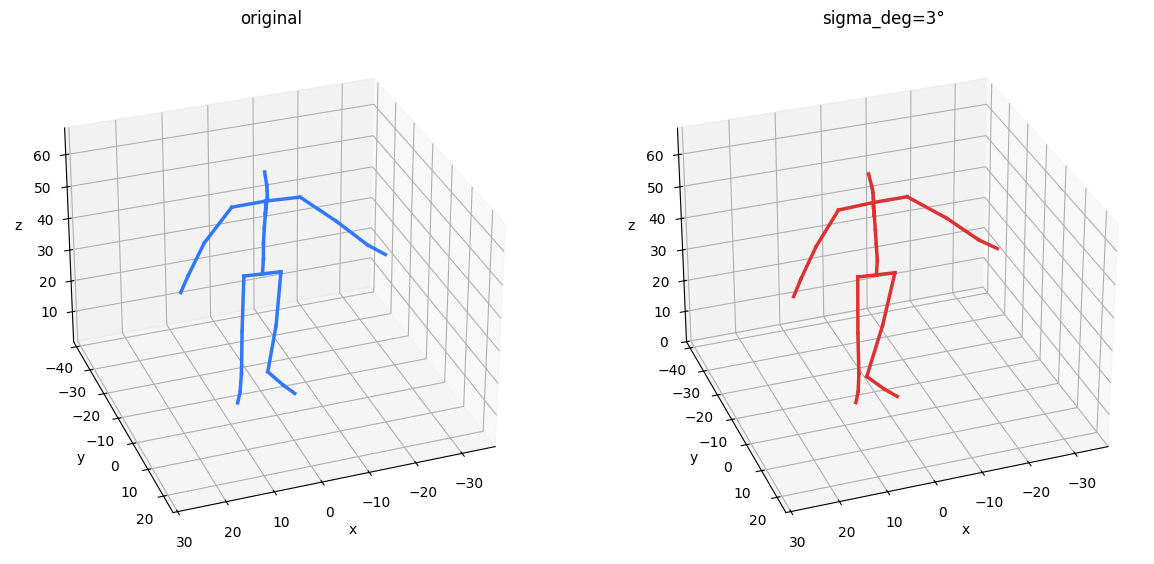

In [14]:
rng = np.random.default_rng(0)
noisy = aug_as_bvh(bvh, add_joint_noise, sigma_deg=3.0, rng=rng)

fig, axes = bvhplot.frame([bvh, noisy],
                          frame=0,
                          labels=["original", "sigma_deg=3°"],
                          camera=(70,30))
plt.show()

## Composition: `AugmentationPipeline` + `set_epoch`

An `AugmentationPipeline` runs a list of `(fn, probability, kwargs)` steps in order.
Kwargs values can be callables of the form `lambda rng: value` — that's how you get
*random* rotation angles on every call rather than a fixed 90° every time.

When you pair the pipeline with a seeded `MotionDataset`, `set_epoch(e)` makes the
per-sample augmentation change across epochs while staying reproducible across runs.
Two different epochs produce *different* tensors; two runs with the same seed and the
same epoch produce *identical* tensors.

In [15]:
from pybvh_ml import AugmentationPipeline
from pybvh_ml.torch import MotionDataset

pipeline = AugmentationPipeline([
    (rotate_vertical, 1.0, {
        "angle_deg": lambda rng: rng.uniform(-180, 180),
        "up_axis": up_axis,
        "representation": "quaternion",
    }),
    (mirror, 0.5, {
        "lr_joint_pairs": lr_pairs,
        "lateral_axis": lateral_axis,
        "representation": "quaternion",
    }),
    (add_joint_noise, 1.0, {"sigma_deg": 2.0, "representation": "quaternion"}),
])

# Build a single-clip dataset from our fixture and inspect the per-epoch behaviour.
root_pos, quats = bvh.to_quaternions()
clip = {"root_pos": root_pos.copy(), "joint_data": quats}

ds_a = MotionDataset([clip], target_length=32, augmentation=pipeline, seed=42)
ds_b = MotionDataset([clip], target_length=32, augmentation=pipeline, seed=42)

ds_a.set_epoch(0); ds_b.set_epoch(0)
same_epoch = (ds_a[0]["data"] == ds_b[0]["data"]).all().item()

ds_a.set_epoch(0); ds_b.set_epoch(1)
diff_epoch = (ds_a[0]["data"] == ds_b[0]["data"]).all().item()

print(f"same seed, same epoch  → identical tensors: {same_epoch}")
print(f"same seed, diff epoch  → identical tensors: {diff_epoch}  (expect False)")

same seed, same epoch  → identical tensors: True
same seed, diff epoch  → identical tensors: False  (expect False)


## Takeaways

- **Array-level augmentations are cheap.** No `Bvh` rebuild, no FK — just numpy.
  That's why they're safe inside `DataLoader` workers.
- **Rotation augmentations are exact.** `rotate_vertical` only touches
  the root; `mirror` uses the analytic quaternion reflection. No Euler
  angles means no gimbal-lock surprises.
- **Order in the pipeline matters.** See the `AugmentationPipeline` docstring for
  the mirror ∘ rotate sign-flip note and the speed-perturbation shape caveat.
- **Reproducibility is opt-in.** `seed=None` gives fresh OS entropy; `seed=<int>`
  + `set_epoch(epoch)` gives deterministic-across-runs, different-per-epoch.